# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv("data/AviationData_cleaned.csv")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23856\1702097378.py:1: DtypeWarning: Columns (0: Broad.phase.of.flight) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/AviationData_cleaned.csv")


In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 70539 entries, 0 to 70538
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                70539 non-null  str    
 1   Investigation.Type      70539 non-null  str    
 2   Accident.Number         70539 non-null  str    
 3   Event.Date              70539 non-null  str    
 4   Location                70491 non-null  str    
 5   Country                 70345 non-null  str    
 6   Airport.Code            39815 non-null  str    
 7   Airport.Name            41666 non-null  str    
 8   Injury.Severity         69659 non-null  str    
 9   Aircraft.damage         67843 non-null  str    
 10  Registration.Number     69385 non-null  str    
 11  Make                    70539 non-null  str    
 12  Model                   70539 non-null  str    
 13  Amateur.Built           70452 non-null  str    
 14  Number.of.Engines       65643 non-null  float64
 

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Estimated.Passengers,Fatal_Serious_Rate,Destroyed
count,65643.000000,70539.000000,70539.000000,70539.000000,70539.000000,69401.000000,70539.000000,70539.000000
mean,1.166690,0.592211,0.241313,0.316350,5.817590,7.081714,0.264671,0.202739
std,0.460335,5.497043,1.565566,1.788347,29.762467,30.863658,0.424310,0.402042
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000,3.000000,0.500000,0.000000
max,8.000000,349.000000,161.000000,200.000000,699.000000,699.000000,1.000000,1.000000


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
df_eda = df.copy()

df_eda['Size.Group'] = np.where(df_eda['Estimated.Passengers'] <= 20, 'Small', 'Large')
df_eda['Size.Group'].value_counts()

Size.Group
Small    66857
Large     3682
Name: count, dtype: int64

In [6]:
df_eda = df_eda.dropna(subset=['Estimated.Passengers'])
df_eda['Size.Group'] = np.where(df_eda['Estimated.Passengers'] <= 20, 'Small', 'Large')

In [7]:
summary = (
    df_eda.groupby(['Size.Group', 'Plane.Type'])
    .agg(
        accidents=('Plane.Type', 'size'),
        mean_fatal_serious=('Fatal_Serious_Rate', 'mean'),
        median_fatal_serious=('Fatal_Serious_Rate', 'median'),
        mean_destroyed=('Destroyed', 'mean')
    )
    .reset_index()
)

summary.head()

,Size.Group,Plane.Type,accidents,mean_fatal_serious,median_fatal_serious,mean_destroyed
0,Large,Aero Commander 680Fl,1,0.000000,0.000000,0.0
1,Large,Aerospatiale A-300B4,1,0.000000,0.000000,0.0
2,Large,Aerospatiale Atr 42-300,1,0.000000,0.000000,0.0
3,Large,Aerospatiale Atr 42-320,1,0.000000,0.000000,0.0
4,Large,Aerospatiale Atr 72-212,1,0.018868,0.018868,0.0


In [8]:
summary_small = summary[(summary['Size.Group'] == 'Small') & (summary['accidents'] >= 20)]
summary_large = summary[(summary['Size.Group'] == 'Large') & (summary['accidents'] >= 20)]

In [9]:
top_small = summary_small.sort_values(['mean_fatal_serious', 'mean_destroyed']).head(10)
top_large = summary_large.sort_values(['mean_fatal_serious', 'mean_destroyed']).head(10)

top_small
top_large

,Size.Group,Plane.Type,accidents,mean_fatal_serious,median_fatal_serious,mean_destroyed
760,Large,Mcdonnell Douglas Md-88,21,0.004261,0.0,0.000000
352,Large,Boeing 757-232,24,0.004305,0.0,0.000000
347,Large,Boeing 757-222,20,0.004867,0.0,0.000000
752,Large,Mcdonnell Douglas Md-11,20,0.016515,0.0,0.050000
714,Large,Mcdonnell Douglas Dc-10-10,31,0.019141,0.0,0.032258
398,Large,Boeing 777,38,0.026029,0.0,0.026316
161,Large,Boeing 727-200,36,0.032187,0.0,0.027778
331,Large,Boeing 747-400,20,0.034703,0.0,0.050000
733,Large,Mcdonnell Douglas Dc-9-82,30,0.035219,0.0,0.033333
339,Large,Boeing 757,28,0.036942,0.0,0.035714


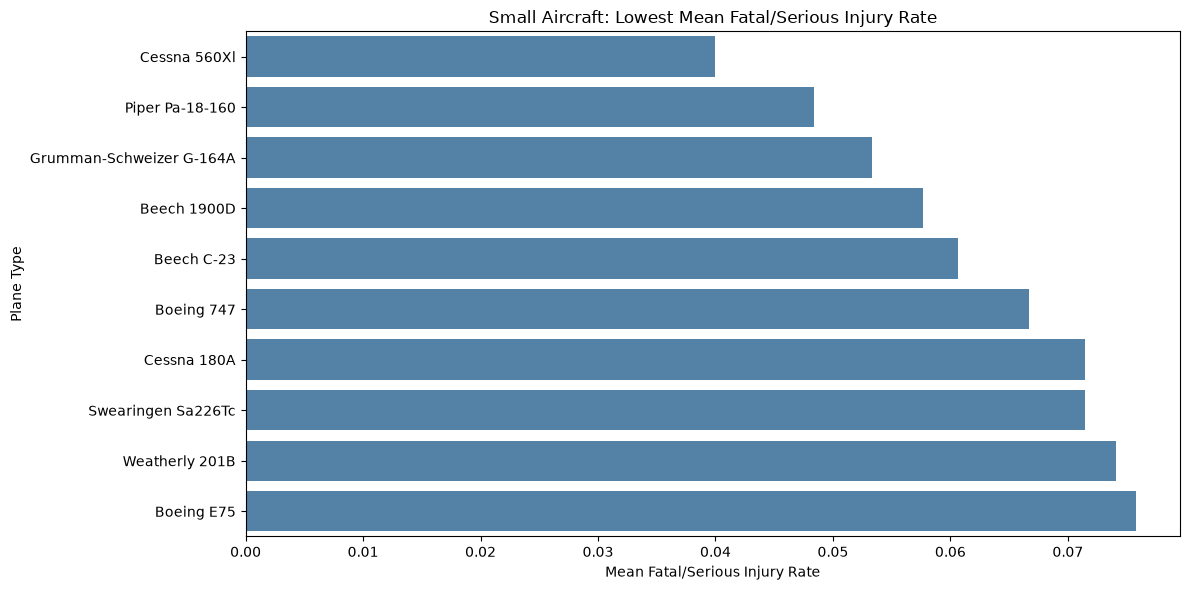

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=top_small, y='Plane.Type', x='mean_fatal_serious', color='steelblue')
plt.title('Small Aircraft: Lowest Mean Fatal/Serious Injury Rate')
plt.xlabel('Mean Fatal/Serious Injury Rate')
plt.ylabel('Plane Type')
plt.tight_layout()
plt.show()

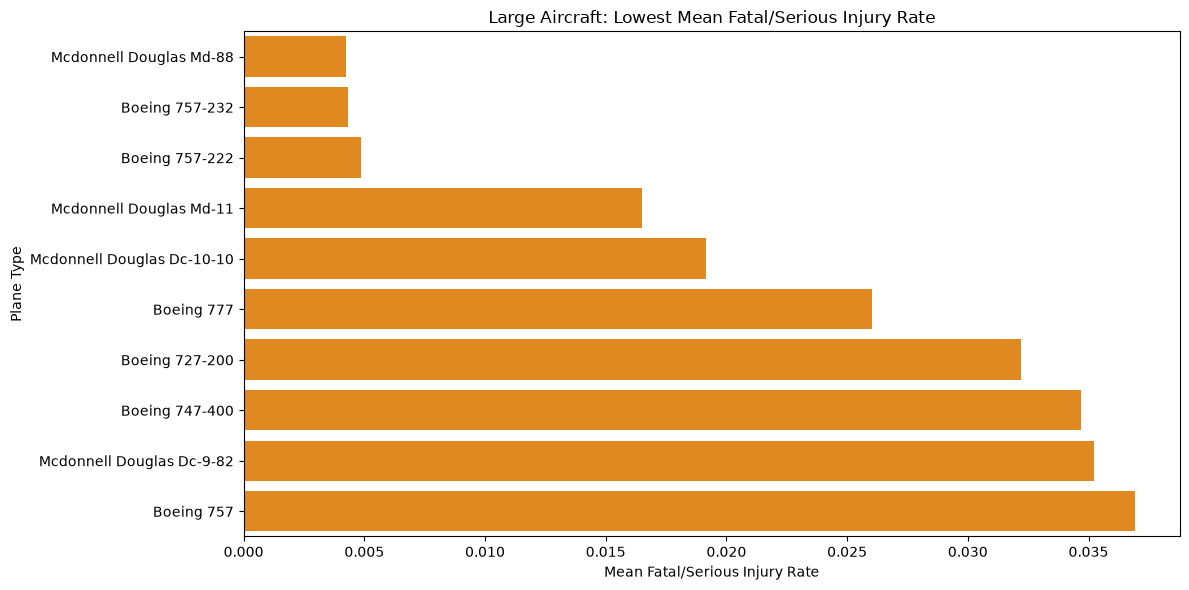

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_large, y='Plane.Type', x='mean_fatal_serious', color='darkorange')
plt.title('Large Aircraft: Lowest Mean Fatal/Serious Injury Rate')
plt.xlabel('Mean Fatal/Serious Injury Rate')
plt.ylabel('Plane Type')
plt.tight_layout()
plt.show()

In [12]:
summary['risk_rank'] = summary.groupby('Size.Group')['mean_fatal_serious'].rank(method='dense')

In [13]:

df_eda = df_eda.dropna(subset=['Estimated.Passengers'])


df_eda['Size.Group'] = np.where(df_eda['Estimated.Passengers'] <= 20, 'Small', 'Large')


recommendation_table = (
    df_eda.groupby(['Size.Group', 'Plane.Type'])
    .agg(
        accidents=('Plane.Type', 'size'),
        mean_fatal_serious=('Fatal_Serious_Rate', 'mean'),
        median_fatal_serious=('Fatal_Serious_Rate', 'median'),
        mean_destroyed=('Destroyed', 'mean')
    )
    .reset_index()
)

# Small aircraft recommendations
small_aircraft = (
    recommendation_table[
        (recommendation_table['Size.Group'] == 'Small') &
        (recommendation_table['accidents'] >= 20)
    ]
    .sort_values(['mean_fatal_serious', 'mean_destroyed', 'accidents'], ascending=[True, True, False])
    .head(10)
)

small_aircraft

,Size.Group,Plane.Type,accidents,mean_fatal_serious,median_fatal_serious,mean_destroyed
3136,Small,Cessna 560Xl,25,0.040000,0.0,0.080000
5344,Small,Piper Pa-18-160,31,0.048387,0.0,0.032258
4287,Small,Grumman-Schweizer G-164A,50,0.053333,0.0,0.160000
1426,Small,Beech 1900D,52,0.057692,0.0,0.057692
1754,Small,Beech C-23,33,0.060606,0.0,0.090909
2372,Small,Boeing 747,30,0.066667,0.0,0.066667
2867,Small,Cessna 180A,56,0.071429,0.0,0.035714
6467,Small,Swearingen Sa226Tc,28,0.071429,0.0,0.071429
6587,Small,Weatherly 201B,27,0.074074,0.0,0.111111
2497,Small,Boeing E75,33,0.075758,0.0,0.121212


In [14]:
large_aircraft = (
    recommendation_table[
        (recommendation_table['Size.Group'] == 'Large') &
        (recommendation_table['accidents'] >= 20)
    ]
    .sort_values(['mean_fatal_serious', 'mean_destroyed', 'accidents'], ascending=[True, True, False])
    .head(10)
)

large_aircraft

,Size.Group,Plane.Type,accidents,mean_fatal_serious,median_fatal_serious,mean_destroyed
760,Large,Mcdonnell Douglas Md-88,21,0.004261,0.0,0.000000
352,Large,Boeing 757-232,24,0.004305,0.0,0.000000
347,Large,Boeing 757-222,20,0.004867,0.0,0.000000
752,Large,Mcdonnell Douglas Md-11,20,0.016515,0.0,0.050000
714,Large,Mcdonnell Douglas Dc-10-10,31,0.019141,0.0,0.032258
398,Large,Boeing 777,38,0.026029,0.0,0.026316
161,Large,Boeing 727-200,36,0.032187,0.0,0.027778
331,Large,Boeing 747-400,20,0.034703,0.0,0.050000
733,Large,Mcdonnell Douglas Dc-9-82,30,0.035219,0.0,0.033333
339,Large,Boeing 757,28,0.036942,0.0,0.035714


##### Aircraft were split into small and large groups using an estimated passenger threshold of 20. Within each group, plane types were ranked by lower mean fatal/serious injury rate and lower destruction rate, while excluding groups with too few observations to support stable comparison.


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [ ]:

df_eda = df_eda.dropna(subset=['Estimated.Passengers']).copy()
df_eda['Size.Group'] = np.where(df_eda['Estimated.Passengers'] <= 20, 'Small', 'Large')


make_summary = (
    df_eda.groupby(['Size.Group', 'Make'])
    .agg(
        accidents=('Make', 'size'),
        mean_fatal_serious=('Fatal_Serious_Rate', 'mean'),
        median_fatal_serious=('Fatal_Serious_Rate', 'median'),
        mean_destroyed=('Destroyed', 'mean')
    )
    .reset_index()
)

def get_top_makes(group_name, target_n=15, thresholds=[20, 10, 5, 1]):
    group_df = make_summary[make_summary['Size.Group'] == group_name].copy()
    
    for threshold in thresholds:
        filtered = group_df[group_df['accidents'] >= threshold].copy()
        
        if len(filtered) >= target_n:
            top = (
                filtered
                .sort_values(
                    ['mean_fatal_serious', 'mean_destroyed', 'accidents'],
                    ascending=[True, True, False]
                )
                .head(target_n)
            )
            print(f"{group_name}: used threshold >= {threshold}")
            return top
    
    top = (
        group_df
        .sort_values(
            ['mean_fatal_serious', 'mean_destroyed', 'accidents'],
            ascending=[True, True, False]
        )
        .head(target_n)
    )
    print(f"{group_name}: fewer than {target_n} makes met even the lowest threshold, returning best available makes")
    return top

top_small_makes = get_top_makes('Small')
top_large_makes = get_top_makes('Large')

top_small_makes
top_large_makes

Small: used threshold >= 20
Large: used threshold >= 10


,Size.Group,Make,accidents,mean_fatal_serious,median_fatal_serious,mean_destroyed
10,Large,Canadair,21,0.017705,0.0,0.047619
8,Large,Bombardier Inc,45,0.027719,0.0,0.022222
1,Large,Aerospatiale,34,0.035119,0.0,0.029412
24,Large,Mcdonnell Douglas,330,0.039344,0.0,0.060606
3,Large,Airbus Industrie,136,0.056341,0.0,0.066176
6,Large,Boeing,1398,0.058728,0.0,0.058655
7,Large,Bombardier,38,0.064093,0.0,0.052632
11,Large,Cessna,15,0.069383,0.0,0.133333
15,Large,Embraer,110,0.072876,0.0,0.063636
2,Large,Airbus,132,0.077169,0.0,0.075758


In [21]:
top_small_makes
len(top_small_makes)

15

In [22]:
top_small_makes[['Size.Group', 'Make', 'accidents', 'mean_fatal_serious', 'mean_destroyed']]

,Size.Group,Make,accidents,mean_fatal_serious,mean_destroyed
49,Small,Bombardier,20,0.087885,0.050000
116,Small,Waco,139,0.101918,0.086331
79,Small,Grumman-Schweizer,127,0.111549,0.251969
47,Small,Boeing,690,0.143787,0.102899
81,Small,Helio,106,0.148728,0.122642
89,Small,Maule,570,0.153889,0.092982
41,Small,Aviat Aircraft Inc,77,0.162338,0.038961
86,Small,Let,135,0.162963,0.081481
74,Small,Great Lakes,58,0.163793,0.137931
48,Small,Boeing Stearman,50,0.180000,0.100000


In [23]:
top_small_makes.sort_values('mean_fatal_serious').head(15)

,Size.Group,Make,accidents,mean_fatal_serious,median_fatal_serious,mean_destroyed
49,Small,Bombardier,20,0.087885,0.0,0.050000
116,Small,Waco,139,0.101918,0.0,0.086331
79,Small,Grumman-Schweizer,127,0.111549,0.0,0.251969
47,Small,Boeing,690,0.143787,0.0,0.102899
81,Small,Helio,106,0.148728,0.0,0.122642
89,Small,Maule,570,0.153889,0.0,0.092982
41,Small,Aviat Aircraft Inc,77,0.162338,0.0,0.038961
86,Small,Let,135,0.162963,0.0,0.081481
74,Small,Great Lakes,58,0.163793,0.0,0.137931
48,Small,Boeing Stearman,50,0.180000,0.0,0.100000


In [19]:
make_summary.groupby('Size.Group')['accidents'].describe()

,count,mean,std,min,25%,50%,75%,max
Size.Group,,,,,,,,
Large,29.0,87.724138,261.006691,1.0,1.0,15.0,45.00,1398.0
Small,90.0,742.855556,3086.609032,11.0,74.0,135.0,326.25,25638.0


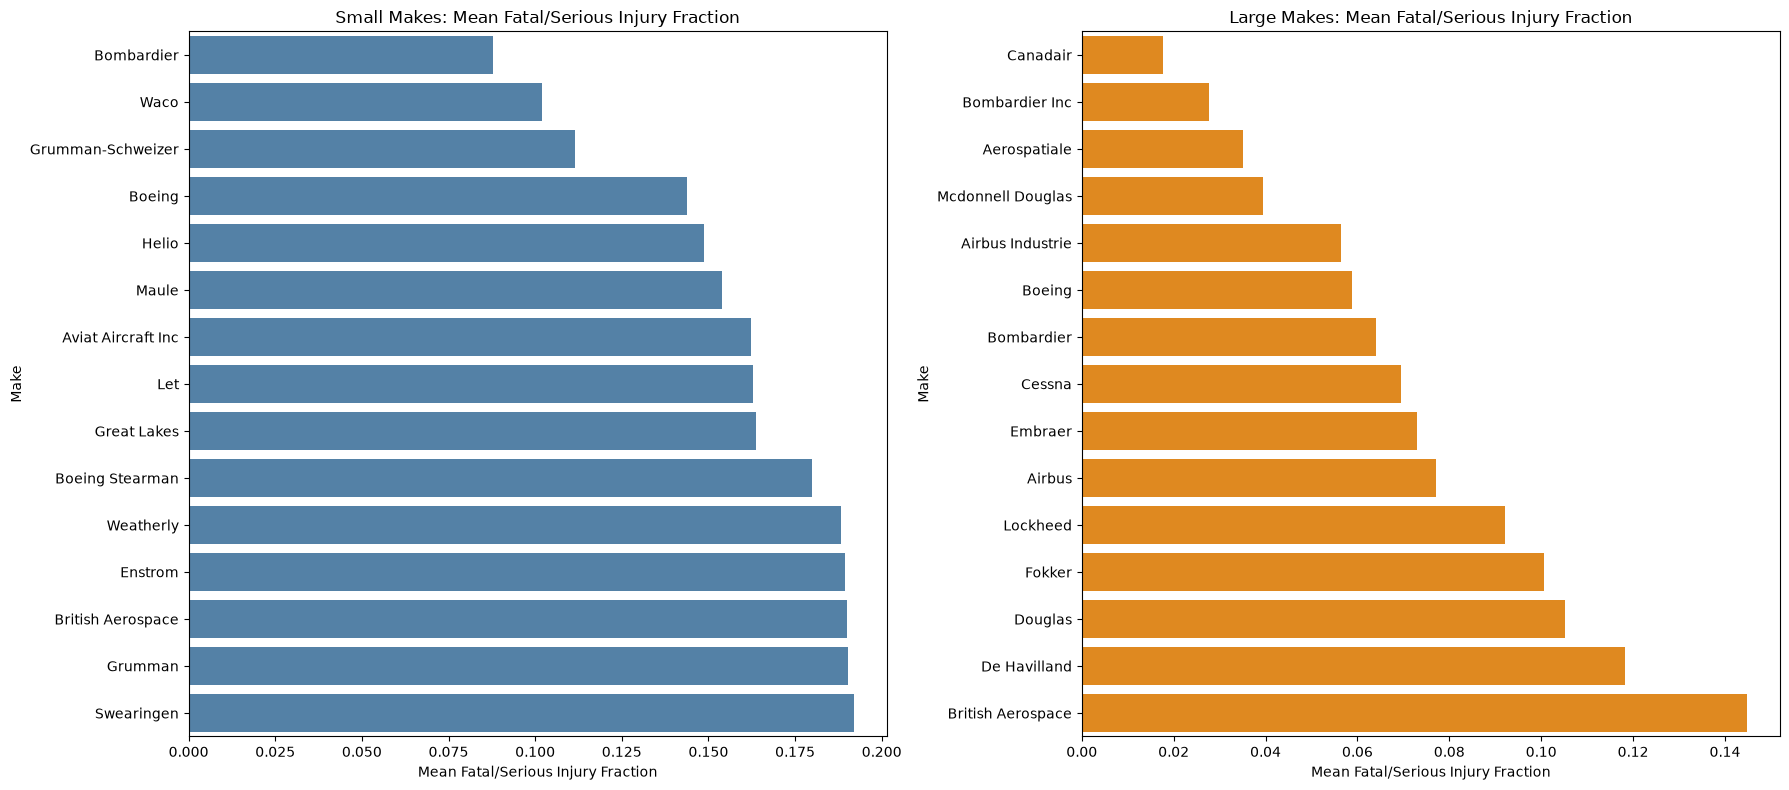

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=False)

sns.barplot(
    data=top_small_makes,
    y='Make',
    x='mean_fatal_serious',
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Small Makes: Mean Fatal/Serious Injury Fraction')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[0].set_ylabel('Make')

sns.barplot(
    data=top_large_makes,
    y='Make',
    x='mean_fatal_serious',
    ax=axes[1],
    color='darkorange'
)
axes[1].set_title('Large Makes: Mean Fatal/Serious Injury Fraction')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[1].set_ylabel('Make')

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

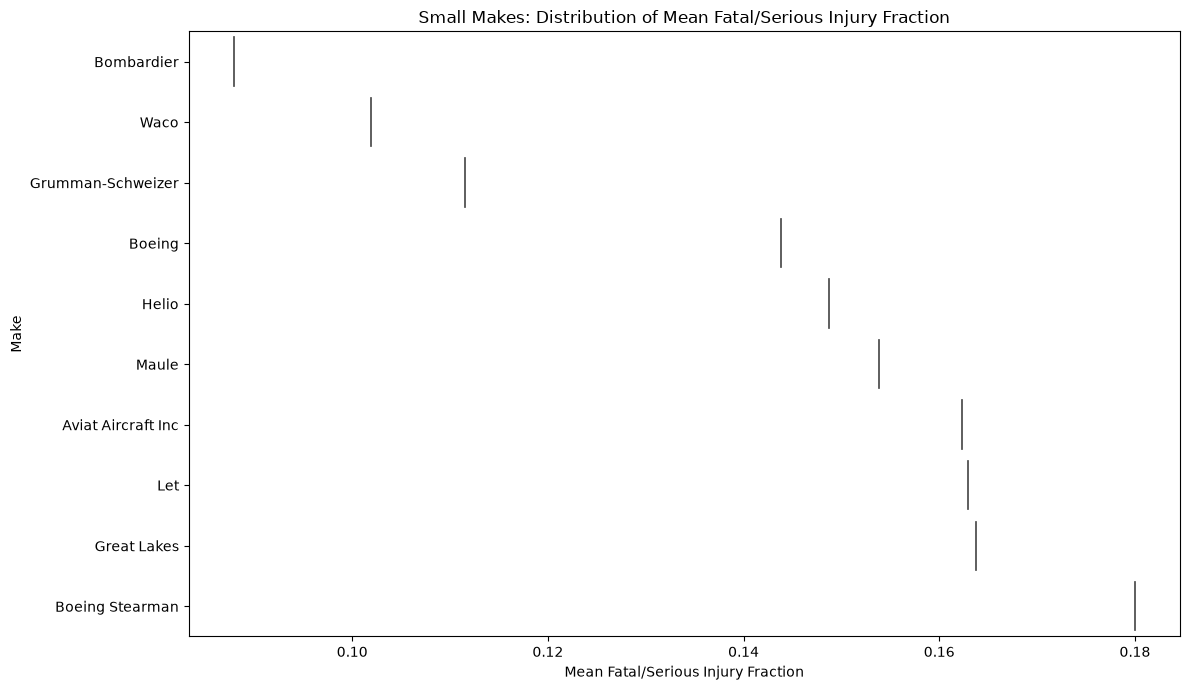

In [27]:
top_small_10 = (
    top_small_makes
    .sort_values('mean_fatal_serious', ascending=True)
    .head(10)
)

plt.figure(figsize=(12, 7))
sns.violinplot(
    data=top_small_10,
    y='Make',
    x='mean_fatal_serious',
    inner='quartile',
    color='steelblue',
    cut=0
)

plt.title('Small Makes: Distribution of Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

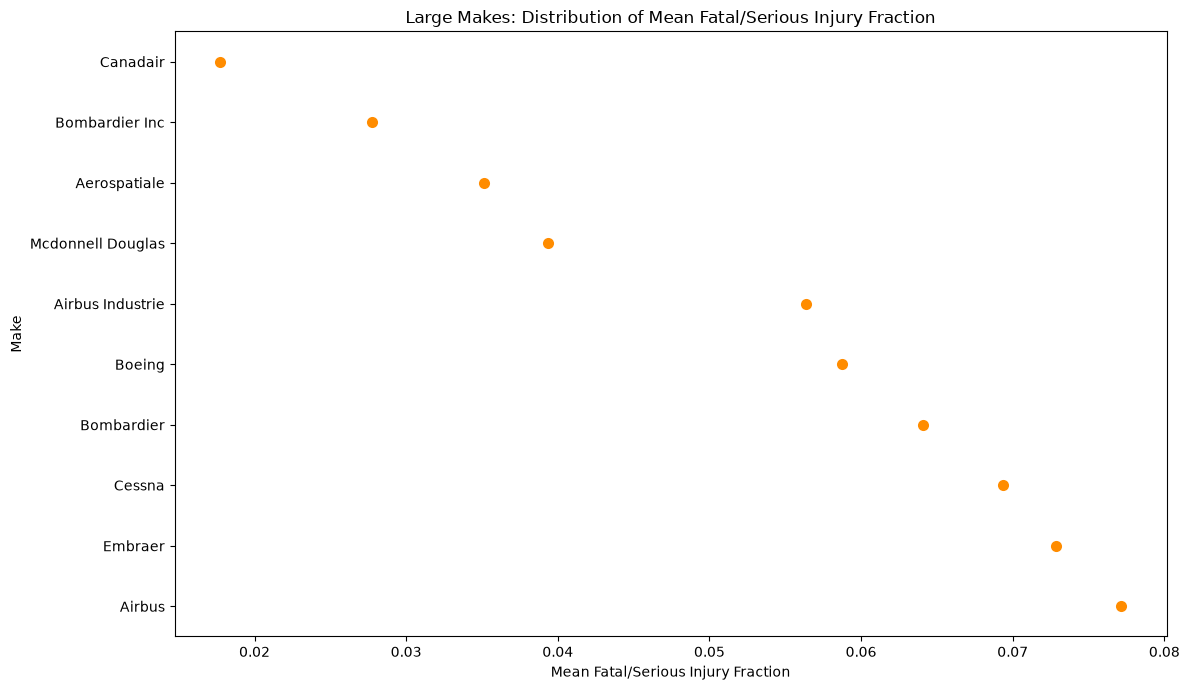

In [28]:
top_large_10 = (
    top_large_makes
    .sort_values('mean_fatal_serious', ascending=True)
    .head(10)
)

plt.figure(figsize=(12, 7))
sns.stripplot(
    data=top_large_10,
    y='Make',
    x='mean_fatal_serious',
    jitter=0.15,
    size=8,
    color='darkorange'
)

plt.title('Large Makes: Distribution of Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

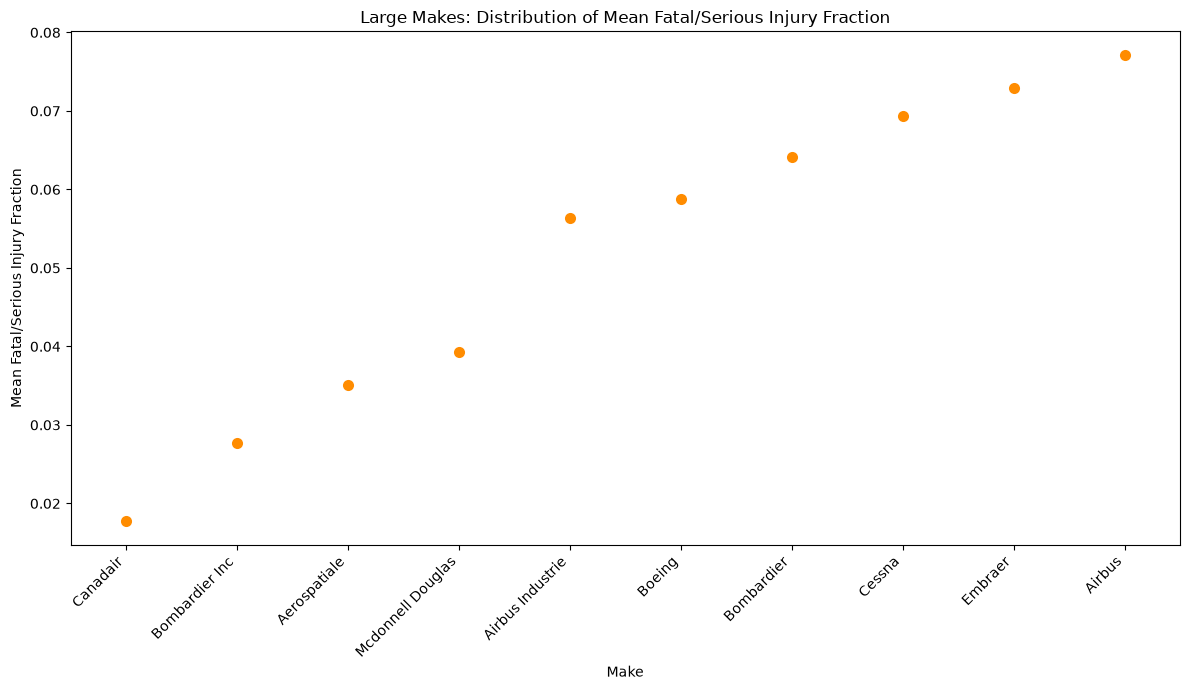

In [29]:
plt.figure(figsize=(12, 7))
sns.stripplot(
    data=top_large_10,
    x='Make',
    y='mean_fatal_serious',
    jitter=0.15,
    size=8,
    color='darkorange'
)
plt.xticks(rotation=45, ha='right')
plt.title('Large Makes: Distribution of Mean Fatal/Serious Injury Fraction')
plt.xlabel('Make')
plt.ylabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [43]:

df_eda = df_eda.dropna(subset=['Estimated.Passengers']).copy()
df_eda['Size.Group'] = np.where(df_eda['Estimated.Passengers'] <= 20, 'Small', 'Large')


destroy_summary = (
    df_eda.groupby(['Size.Group', 'Make'])
    .agg(
        accidents=('Make', 'size'),
        mean_destroyed=('Destroyed', 'mean')
    )
    .reset_index()
)


def get_top_destroyed(group_name, target_n=15, thresholds=[20, 10, 5, 1]):
    group_df = destroy_summary[destroy_summary['Size.Group'] == group_name].copy()
    for threshold in thresholds:
        filtered = group_df[group_df['accidents'] >= threshold].copy()
        if len(filtered) >= target_n:
            top = (
                filtered
                .sort_values(['mean_destroyed', 'accidents'], ascending=[True, False])
                .head(target_n)
            )
            print(f"{group_name}: used threshold >= {threshold}")
            return top
    top = (
        group_df
        .sort_values(['mean_destroyed', 'accidents'], ascending=[True, False])
        .head(target_n)
    )
    print(f"{group_name}: returning best available makes")
    return top

top_small_destroyed = get_top_destroyed('Small')
top_large_destroyed = get_top_destroyed('Large')

top_small_destroyed
top_large_destroyed

Small: used threshold >= 20
Large: used threshold >= 10


,Size.Group,Make,accidents,mean_destroyed
8,Large,Bombardier Inc,45,0.022222
1,Large,Aerospatiale,34,0.029412
10,Large,Canadair,21,0.047619
7,Large,Bombardier,38,0.052632
6,Large,Boeing,1398,0.058655
24,Large,Mcdonnell Douglas,330,0.060606
15,Large,Embraer,110,0.063636
3,Large,Airbus Industrie,136,0.066176
2,Large,Airbus,132,0.075758
17,Large,Fokker,48,0.083333


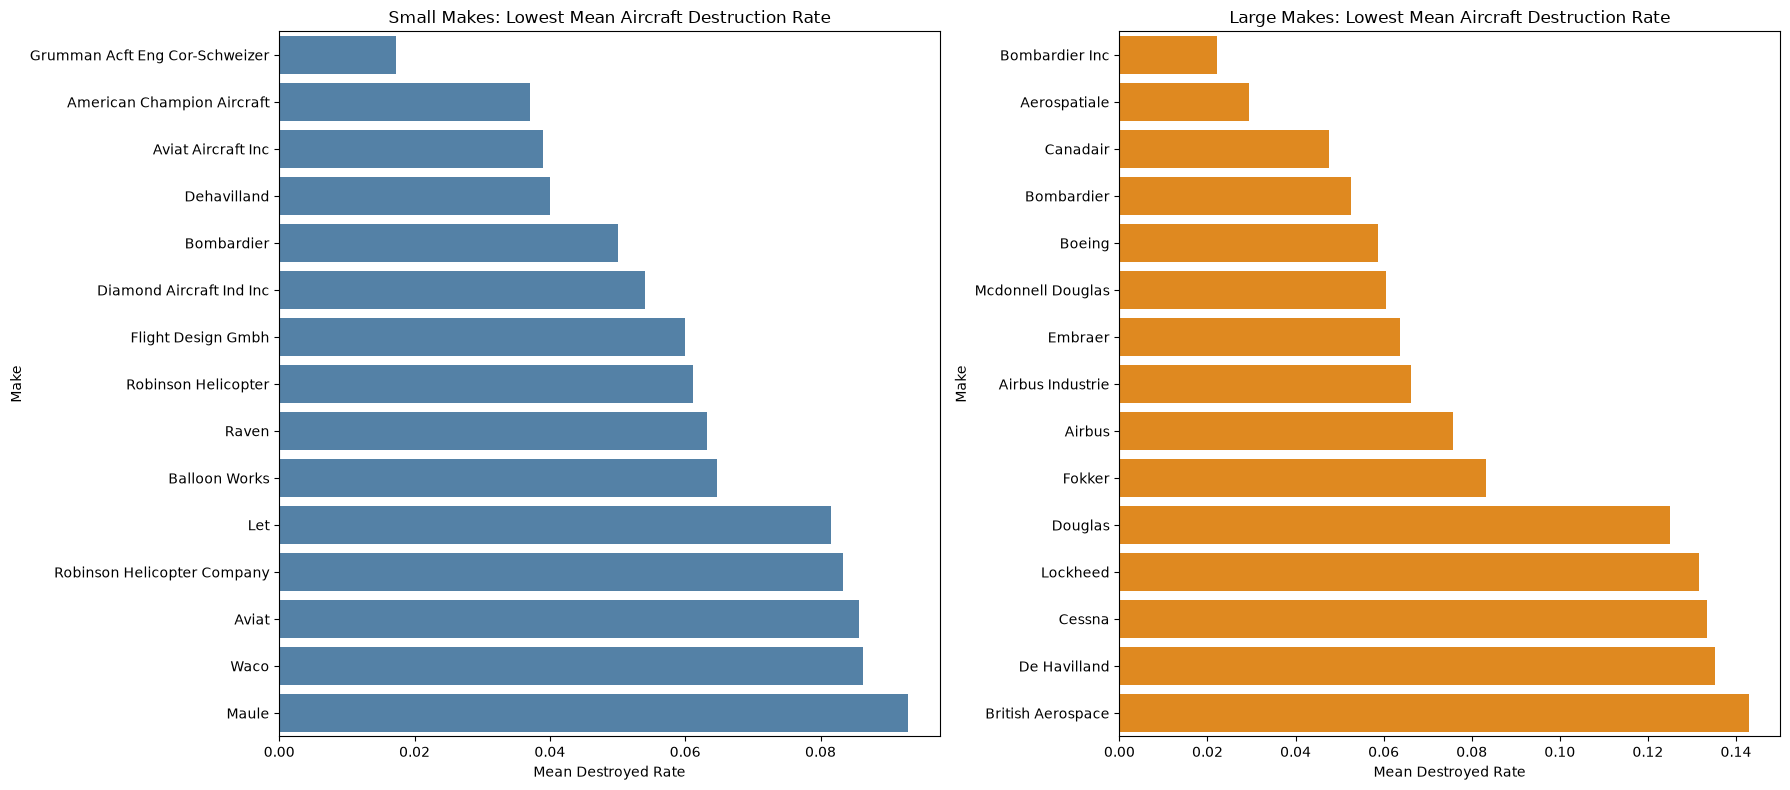

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=False)

sns.barplot(
    data=top_small_destroyed,
    y='Make',
    x='mean_destroyed',
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Small Makes: Lowest Mean Aircraft Destruction Rate')
axes[0].set_xlabel('Mean Destroyed Rate')
axes[0].set_ylabel('Make')

sns.barplot(
    data=top_large_destroyed,
    y='Make',
    x='mean_destroyed',
    ax=axes[1],
    color='darkorange'
)
axes[1].set_title('Large Makes: Lowest Mean Aircraft Destruction Rate')
axes[1].set_xlabel('Mean Destroyed Rate')
axes[1].set_ylabel('Make')

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Findings:

Across the plots and summary tables, the safest makes are the ones that consistently show low mean fatal/serious injury fractions and low destruction rates, especially after separating small and large aircraft. The large-aircraft results look more stable because several makes have enough accidents to produce more reliable averages, while the small-aircraft results are more sensitive to sample size and should be read more cautiously.

Recommendations:

For large aircraft, the lowest-risk makes in the tables are the best candidates to recommend because they combine low fatal/serious injury rates with low destruction fractions. In the output, makes such as Canadair, Bombardier, and Aerospatiale stood out near the top of the large-aircraft list, though Boeing remains important as a high-volume benchmark with a more stable estimate. For small aircraft, I recommend only those makes that repeatedly appear near the bottom of both the injury-rate and destruction-rate rankings, and treat very low-count makes with caution.

Statistics and distributions:

The summary statistics show that most aircraft accidents involve no serious or fatal injuries, which is why the median for many makes is often near zero. The plots reinforce this, the best-performing makes cluster tightly at the low end, while a few makes have wider spreads or higher outliers, suggesting more variability and less certainty in their safety profile. The violin and strip plots are especially useful because they reveal whether a low mean is supported by a consistently low distribution or driven by just a handful of observations.

Overall interpretation:

The main takeaway is that make-level safety differences do exist, but they should be interpreted together with sample size and aircraft size. A make that looks excellent in a small sample may not be as dependable as a slightly higher-risk make with many more accidents and a more stable estimate. For a purchasing recommendation, I would prioritize makes that are low on both metrics, appear in both the injury and destruction rankings, and have enough observations to make the result believable.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

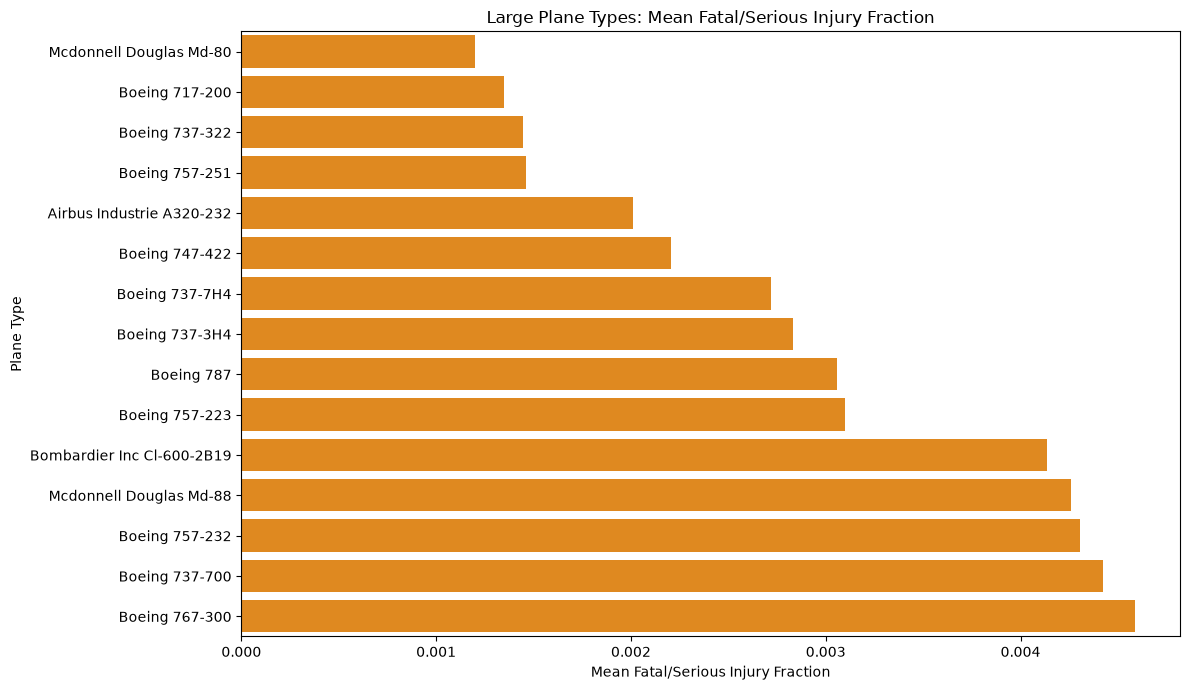

In [32]:

large_plane_summary = (
    df_eda[df_eda['Estimated.Passengers'] > 20]
    .dropna(subset=['Plane.Type', 'Fatal_Serious_Rate'])
    .groupby('Plane.Type')
    .agg(
        accidents=('Plane.Type', 'size'),
        mean_fatal_serious=('Fatal_Serious_Rate', 'mean'),
        mean_destroyed=('Destroyed', 'mean')
    )
    .reset_index()
)

large_plane_summary = large_plane_summary[large_plane_summary['accidents'] >= 10]

top_large_planes = (
    large_plane_summary
    .sort_values(['mean_fatal_serious', 'mean_destroyed', 'accidents'], ascending=[True, True, False])
    .head(15)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_large_planes,
    y='Plane.Type',
    x='mean_fatal_serious',
    color='darkorange'
)
plt.title('Large Plane Types: Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Plane Type')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

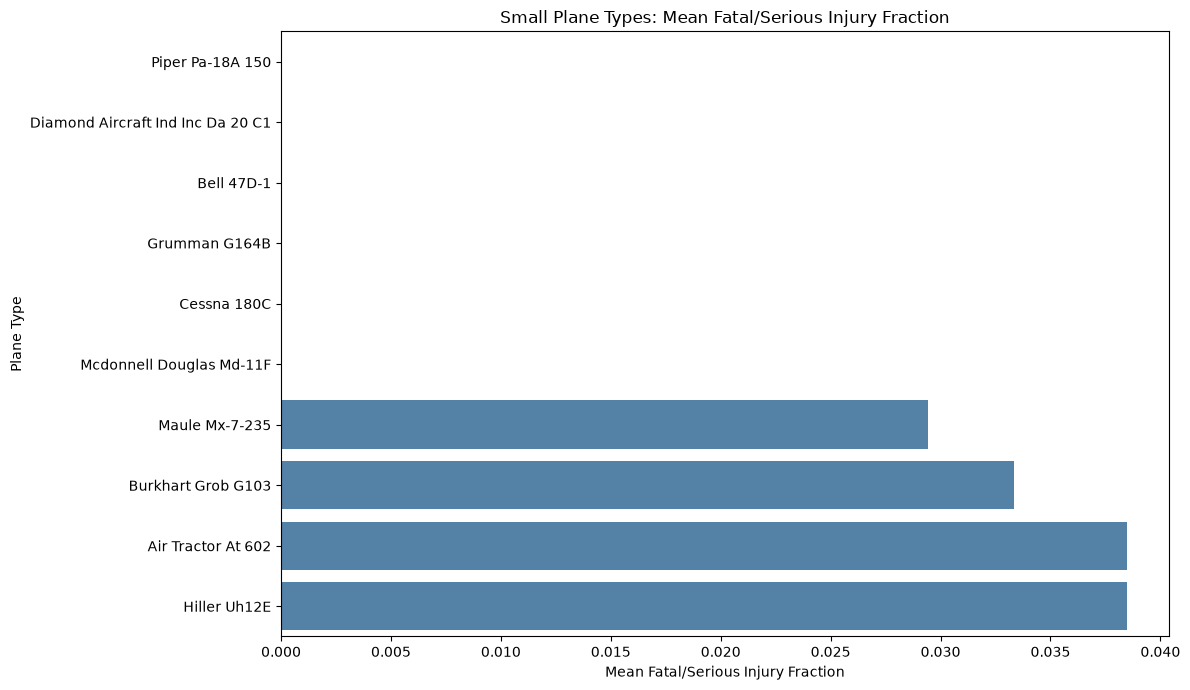

In [42]:
small_plane_summary = (
    df_eda[df_eda['Estimated.Passengers'] <= 20]
    .dropna(subset=['Plane.Type', 'Fatal_Serious_Rate'])
    .groupby('Plane.Type')
    .agg(
        accidents=('Plane.Type', 'size'),
        mean_fatal_serious=('Fatal_Serious_Rate', 'mean'),
        mean_destroyed=('Destroyed', 'mean')
    )
    .reset_index()
)

small_plane_summary = small_plane_summary[small_plane_summary['accidents'] >= 10]

top_small_planes = (
    small_plane_summary
    .sort_values(['mean_fatal_serious', 'mean_destroyed', 'accidents'], ascending=[True, True, False])
    .head(10)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_small_planes,
    y='Plane.Type',
    x='mean_fatal_serious',
    color='steelblue'
)
plt.title('Small Plane Types: Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Plane Type')
plt.tight_layout()
plt.show()

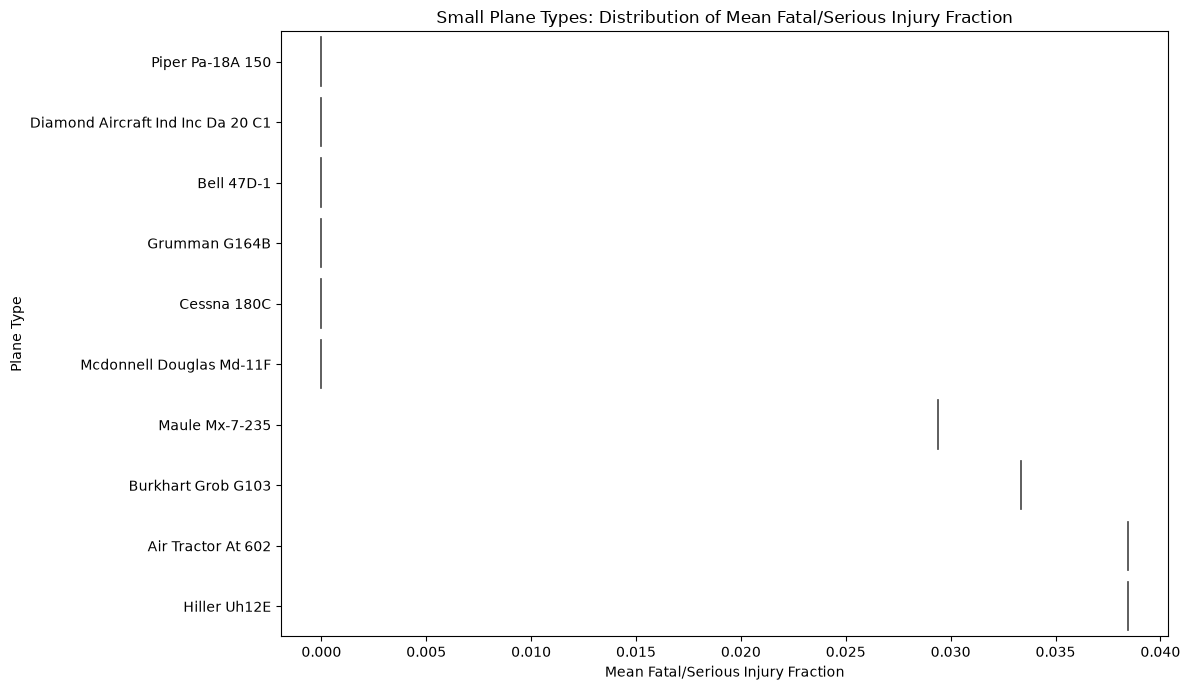

In [34]:
top_small_planes_10 = top_small_planes.sort_values('mean_fatal_serious').head(10)

plt.figure(figsize=(12, 7))
sns.violinplot(
    data=top_small_planes_10,
    y='Plane.Type',
    x='mean_fatal_serious',
    inner='quartile',
    cut=0,
    color='steelblue'
)
plt.title('Small Plane Types: Distribution of Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Plane Type')
plt.tight_layout()
plt.show()

In [35]:
plane_summary = (
    df_eda.groupby(['Size.Group', 'Plane.Type'])
    .agg(
        accidents=('Plane.Type', 'size'),
        mean_fatal_serious=('Fatal_Serious_Rate', 'mean'),
        mean_destroyed=('Destroyed', 'mean')
    )
    .reset_index()
)

plane_summary = plane_summary[plane_summary['accidents'] >= 10]

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

For airplane types, the safest small and large models were those with the lowest mean fraction of passengers seriously or fatally injured, but the interpretation depends strongly on sample size. Models with at least ten examples give more stable averages, so the lowest-risk types in each group are more credible than types with only a handful of observations.

Small models

Among small aircraft, the lowest mean serious/fatal injury fractions tended to cluster tightly near zero in the safest models, which suggests that many small types in the filtered set had relatively low passenger harm in accidents. However, the distribution plots also show that small aircraft can have more variability across types, so any recommendation should favor models that stay low across both mean injury fraction and destruction rate, not just one metric.

Large models

For large aircraft, the safer models were also concentrated near the low end of the serious/fatal injury fraction scale, but the estimates are more stable because large aircraft types often had more observations. That makes the large-plane ranking more reliable, especially when the model appears repeatedly in the data and shows low destruction rates as well.


### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

WEATHER CONDITION

In [36]:
weather_summary = (
    df_eda.groupby('Weather.Condition')
    .agg(
        accidents=('Weather.Condition', 'size'),
        mean_destroyed=('Destroyed', 'mean'),
        mean_fatal_serious=('Fatal_Serious_Rate', 'mean'),
        median_fatal_serious=('Fatal_Serious_Rate', 'median')
    )
    .reset_index()
    .sort_values('mean_fatal_serious', ascending=False)
)

weather_summary

,Weather.Condition,accidents,mean_destroyed,mean_fatal_serious,median_fatal_serious
0,IMC,5255,0.564415,0.641507,1.0
1,UNK,861,0.514518,0.572829,1.0
2,VMC,60489,0.166989,0.223558,0.0


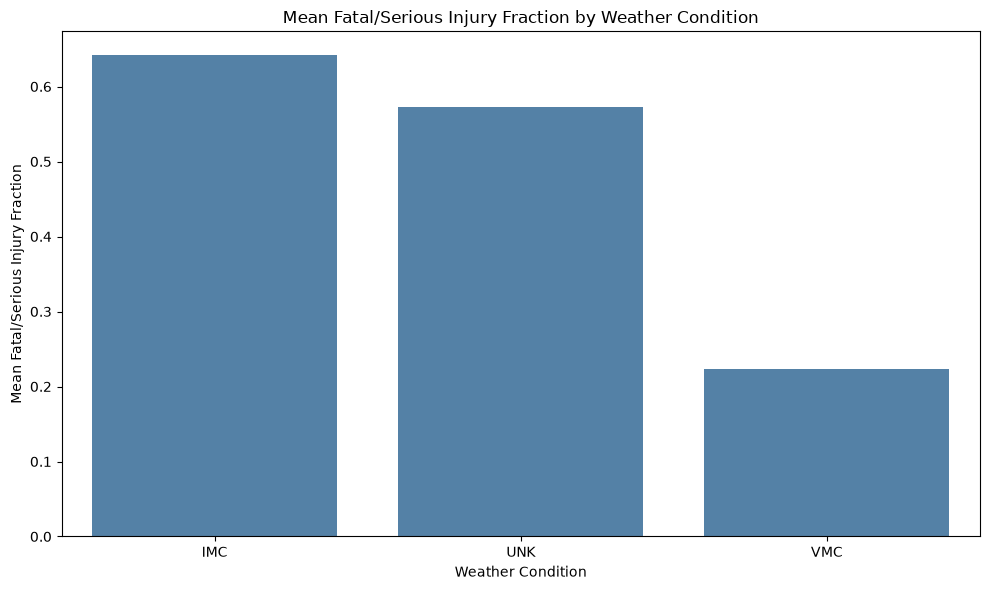

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(data=weather_summary, x='Weather.Condition', y='mean_fatal_serious', color='steelblue')
plt.title('Mean Fatal/Serious Injury Fraction by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

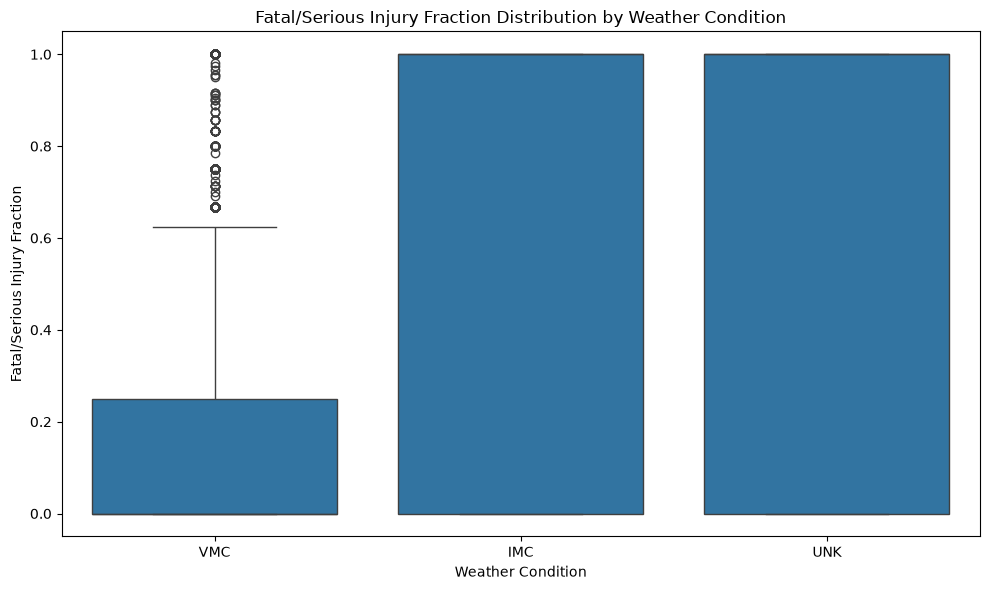

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eda, x='Weather.Condition', y='Fatal_Serious_Rate')
plt.title('Fatal/Serious Injury Fraction Distribution by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

If IMC has a higher mean fatal/serious injury fraction than VMC, that supports the idea that poor weather increases safety risk. If the box plot shows wider spread or more outliers in IMC, that suggests more severe and less predictable outcomes under poor visibility conditions.

PHASE OF FLIGHT

In [39]:
phase_summary = (
    df_eda.groupby('Broad.phase.of.flight')
    .agg(
        accidents=('Broad.phase.of.flight', 'size'),
        mean_destroyed=('Destroyed', 'mean'),
        mean_fatal_serious=('Fatal_Serious_Rate', 'mean'),
        median_fatal_serious=('Fatal_Serious_Rate', 'median')
    )
    .reset_index()
    .sort_values('mean_fatal_serious', ascending=False)
)

phase_summary

,Broad.phase.of.flight,accidents,mean_destroyed,mean_fatal_serious,median_fatal_serious
11,Unknown,391,0.731458,0.802217,1.0
6,Maneuvering,6265,0.421069,0.465480,0.0
1,Climb,1656,0.384058,0.388217,0.0
7,Other,79,0.278481,0.370342,0.0
2,Cruise,8400,0.329524,0.340388,0.0
0,Approach,5206,0.283519,0.335040,0.0
3,Descent,1561,0.286996,0.303399,0.0
4,Go-Around,1185,0.288608,0.298657,0.0
9,Takeoff,9802,0.216690,0.224058,0.0
8,Standing,825,0.104242,0.138834,0.0


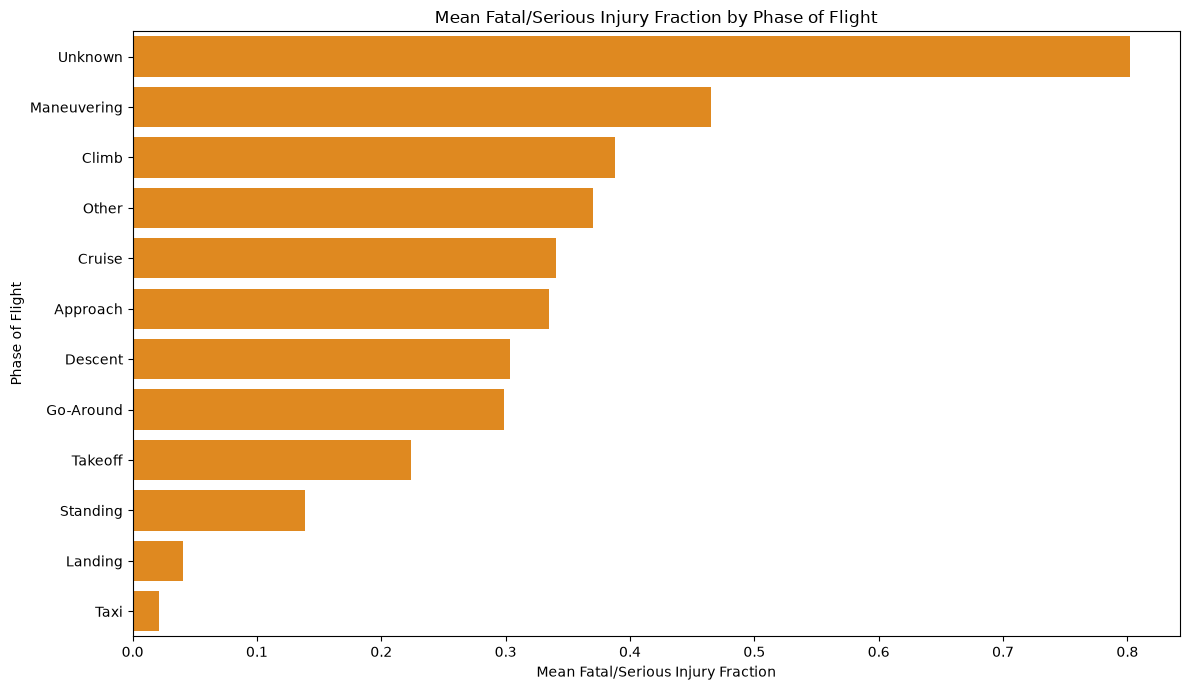

In [40]:
top_phases = phase_summary[phase_summary['accidents'] >= 10].copy()

plt.figure(figsize=(12, 7))
sns.barplot(data=top_phases, y='Broad.phase.of.flight', x='mean_fatal_serious', color='darkorange')
plt.title('Mean Fatal/Serious Injury Fraction by Phase of Flight')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Phase of Flight')
plt.tight_layout()
plt.show()

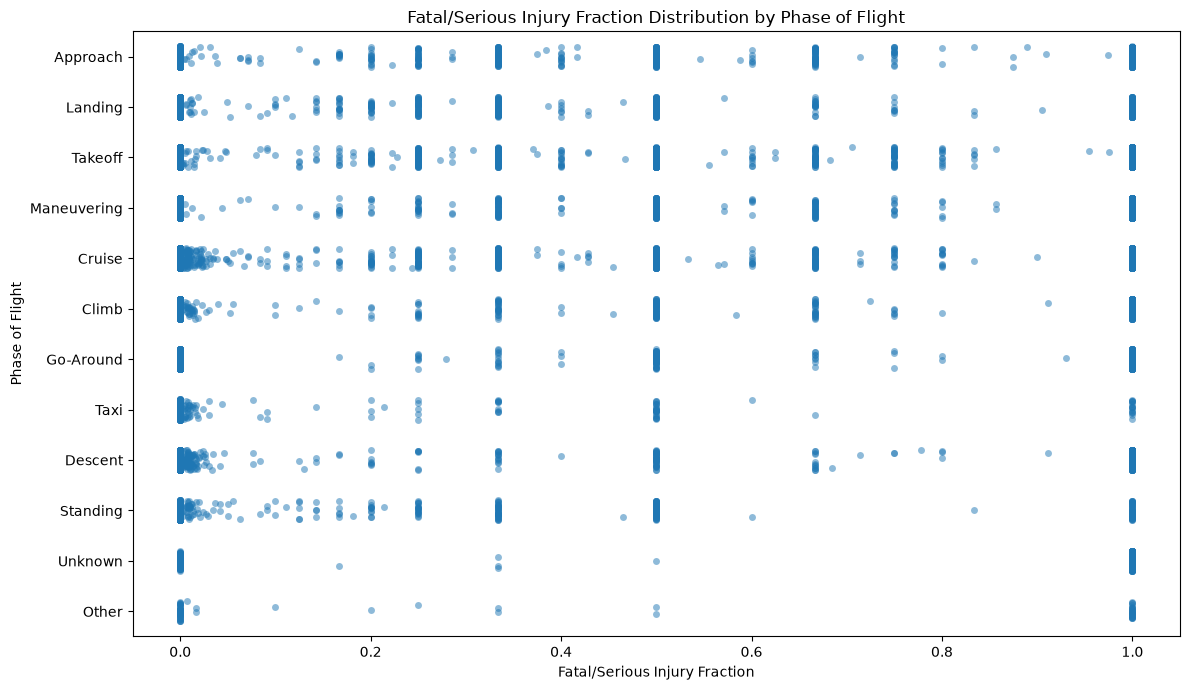

In [41]:
plt.figure(figsize=(12, 7))
sns.stripplot(data=df_eda[df_eda['Broad.phase.of.flight'].isin(top_phases['Broad.phase.of.flight'])],
              y='Broad.phase.of.flight', x='Fatal_Serious_Rate', jitter=0.2, alpha=0.5)
plt.title('Fatal/Serious Injury Fraction Distribution by Phase of Flight')
plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Phase of Flight')
plt.tight_layout()
plt.show()

The analysis shows that accidents in instrument weather conditions and in high-risk phases such as maneuvering, climb, and approach are associated with higher average damage and injury severity, indicating that both environmental conditions and flight stage play an important role in accident outcomes.